<a href="https://colab.research.google.com/github/eqychen23/NBA-Project/blob/main/NBA_Offensive_Effectiveness_25_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **NBA Offensive Effectiveness Project**

  Welcome to my project on NBA Offensive Effectivness, where I am looking to see if Python's unsupervised learning capabilities (K-Means clustering) and offensive tier classifications can successfully group the league's talent into related statistical profiles, based on offensive statistics and efficiency metrics.

  I will be utilizing data from Basketball Reference for the 2025-26 regular season, and I am specifically going to be using the individual statistics of players **Per 100 Possessions** because it normalizes for *pace* and overall *playing style*, so that players who play for teams that don't play untempo are on a level playing field with those who do.
  
  Before I begin conducting my analyses, here are some key definitions of the statistics (and abbreviations) I'll be using.


**1.** PTS: Points Per 100 Possessions

**2.** AST: Assists Per 100 Possessions

**3.** TRB: Total Rebounds Per 100 Possessions

**4.** FGA: Field Goals Attempted

**5.** FT%: Free Throw Percentage

**6.** ORtg: Offensive Rating (points produced per 100 possessions)

**7.** eFG%: Traditional FG percentage (made shots/total shots) adjusted to account for the extra value of 3-point shots

### Pulling the Data


In [ ]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans



In [ ]:
import pandas as pd

player_df = pd.read_csv("nba_2026_per_100.csv")

print(player_df.shape)
print(player_df[["Player", "Team", "PTS"]].head())

(733, 34)
             Player Team   PTS
0     Amen Thompson  HOU  24.4
1      Kevin Durant  HOU  35.6
2      Desmond Bane  ORL  28.7
3    Toumani Camara  POR  19.2
4  Jabari Smith Jr.  HOU  22.4


In [ ]:
#shorten the list to just Player, Pos, eFG%, FT%, PTS, AST, TRB, ORtg, MP
necessary_col = ['Player','Team','Pos', 'MP', 'G','FGA','eFG%', 'FT%', 'PTS', 'AST', 'TRB', 'ORtg']
player_df = player_df[necessary_col]
player_df.head(10)


,Player,Team,Pos,MP,G,FGA,eFG%,FT%,PTS,AST,TRB,ORtg
0,Amen Thompson,HOU,PG,2953,79,17.7,0.545,0.779,24.4,7.1,10.4,125.0
1,Kevin Durant,HOU,SF,2840,78,24.2,0.588,0.874,35.6,6.5,7.5,124.0
2,Desmond Bane,ORL,SG,2756,82,21.0,0.553,0.908,28.7,5.9,5.9,120.0
3,Toumani Camara,POR,PF,2731,82,15.6,0.563,0.708,19.2,3.5,7.4,115.0
4,Jabari Smith Jr.,HOU,PF,2705,77,18.0,0.541,0.775,22.4,2.6,9.8,120.0
5,Mikal Bridges,NYK,SF,2692,82,17.7,0.571,0.827,21.8,5.6,5.7,125.0
6,Scottie Barnes,TOR,PF,2681,80,20.4,0.537,0.815,26.3,8.6,10.9,116.0
7,Tyrese Maxey,PHI,PG,2661,70,27.2,0.536,0.892,35.9,8.4,5.3,120.0
8,Jamal Murray,DEN,PG,2652,75,25.0,0.573,0.887,35.1,9.8,6.1,126.0
9,Derrick White,BOS,SG,2625,77,21.4,0.489,0.902,24.4,8.0,6.5,117.0


In [ ]:
#rename some of the columns
player_df_rename = player_df.copy()

player_df_rename = player_df.rename(columns={'MP':'Minutes Played', 'G': 'Games'})

#new column to define minutes per game
player_df_rename['Min_per_game'] = round(player_df_rename['Minutes Played'] / player_df_rename['Games'], 2)

player_df_rename.head(10)

,Player,Team,Pos,Minutes Played,Games,FGA,eFG%,FT%,PTS,AST,TRB,ORtg,Min_per_game
0,Amen Thompson,HOU,PG,2953,79,17.7,0.545,0.779,24.4,7.1,10.4,125.0,37.38
1,Kevin Durant,HOU,SF,2840,78,24.2,0.588,0.874,35.6,6.5,7.5,124.0,36.41
2,Desmond Bane,ORL,SG,2756,82,21.0,0.553,0.908,28.7,5.9,5.9,120.0,33.61
3,Toumani Camara,POR,PF,2731,82,15.6,0.563,0.708,19.2,3.5,7.4,115.0,33.30
4,Jabari Smith Jr.,HOU,PF,2705,77,18.0,0.541,0.775,22.4,2.6,9.8,120.0,35.13
5,Mikal Bridges,NYK,SF,2692,82,17.7,0.571,0.827,21.8,5.6,5.7,125.0,32.83
6,Scottie Barnes,TOR,PF,2681,80,20.4,0.537,0.815,26.3,8.6,10.9,116.0,33.51
7,Tyrese Maxey,PHI,PG,2661,70,27.2,0.536,0.892,35.9,8.4,5.3,120.0,38.01
8,Jamal Murray,DEN,PG,2652,75,25.0,0.573,0.887,35.1,9.8,6.1,126.0,35.36
9,Derrick White,BOS,SG,2625,77,21.4,0.489,0.902,24.4,8.0,6.5,117.0,34.09


At this point is where I would look to clean some of the data. However, pulling the data directly from Basketball Reference and filtering just for player statistics made it so that I don't have any definitive missing values ONLY if that player played a significant amount of minutes or games. I will filter for that below.

In [ ]:
# Clean some of the data
#Basketball Reference data is generally clean, however, I want to create constraints with our data

#Min Per Game > 25, FGA (per 100) > 12. This helps us get players who actively played a lot of minutes & was active in offense.

player_df_rename = player_df_rename[(player_df_rename['Min_per_game'] > 25) & (player_df_rename['FGA'] > 12) & (player_df_rename['Minutes Played']>1300)]

print(player_df_rename.head(10))

print(player_df_rename.shape)

# This gives us 150 players to analyze.

             Player Team Pos  Minutes Played  Games   FGA   eFG%    FT%   PTS  \
0     Amen Thompson  HOU  PG            2953     79  17.7  0.545  0.779  24.4   
1      Kevin Durant  HOU  SF            2840     78  24.2  0.588  0.874  35.6   
2      Desmond Bane  ORL  SG            2756     82  21.0  0.553  0.908  28.7   
3    Toumani Camara  POR  PF            2731     82  15.6  0.563  0.708  19.2   
4  Jabari Smith Jr.  HOU  PF            2705     77  18.0  0.541  0.775  22.4   
5     Mikal Bridges  NYK  SF            2692     82  17.7  0.571  0.827  21.8   
6    Scottie Barnes  TOR  PF            2681     80  20.4  0.537  0.815  26.3   
7      Tyrese Maxey  PHI  PG            2661     70  27.2  0.536  0.892  35.9   
8      Jamal Murray  DEN  PG            2652     75  25.0  0.573  0.887  35.1   
9     Derrick White  BOS  SG            2625     77  21.4  0.489  0.902  24.4   

   AST   TRB   ORtg  Min_per_game  
0  7.1  10.4  125.0         37.38  
1  6.5   7.5  124.0         36.41  



## Quick Look at the Distribution of Statistics

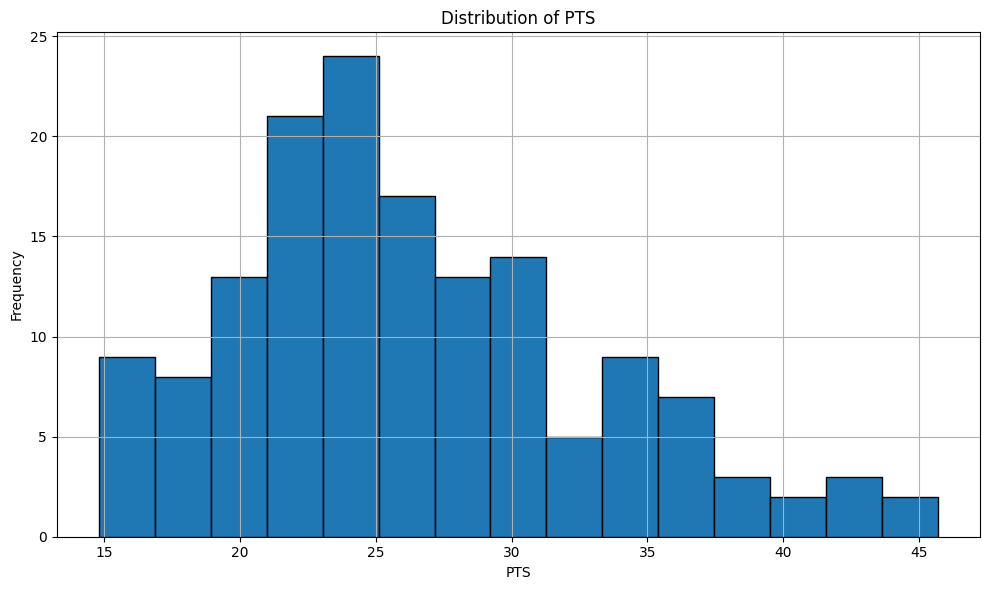

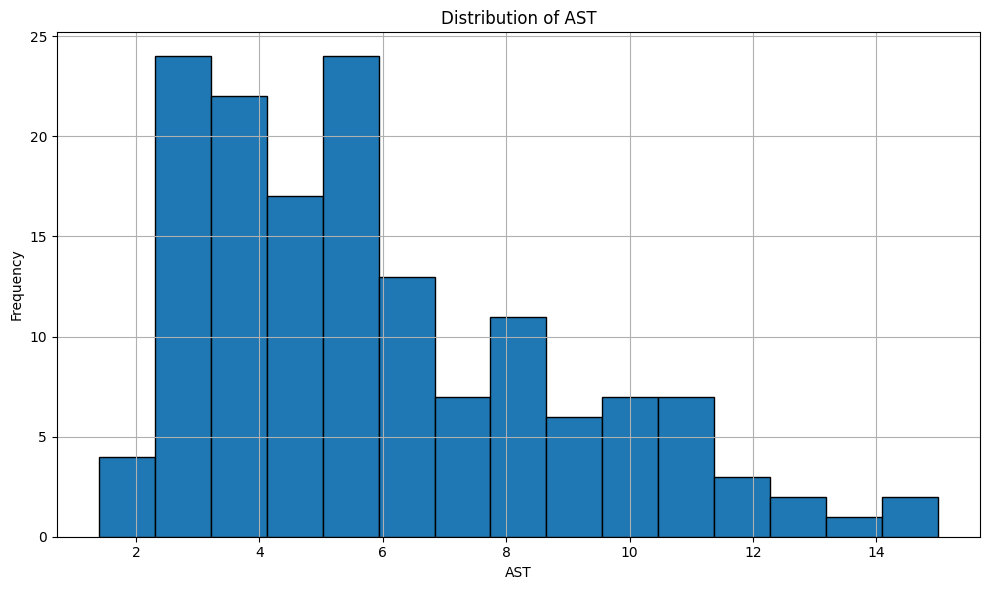

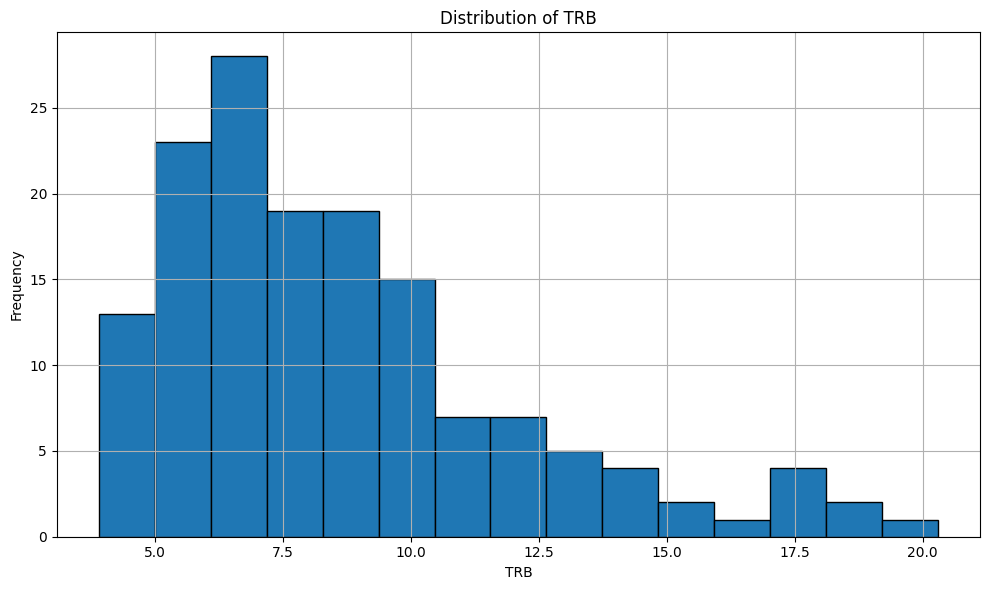

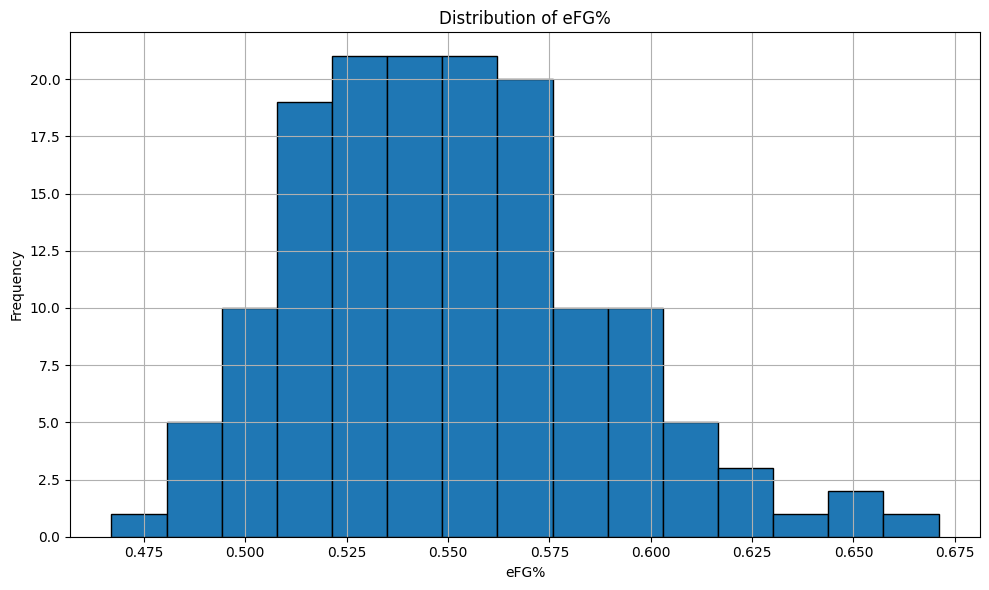

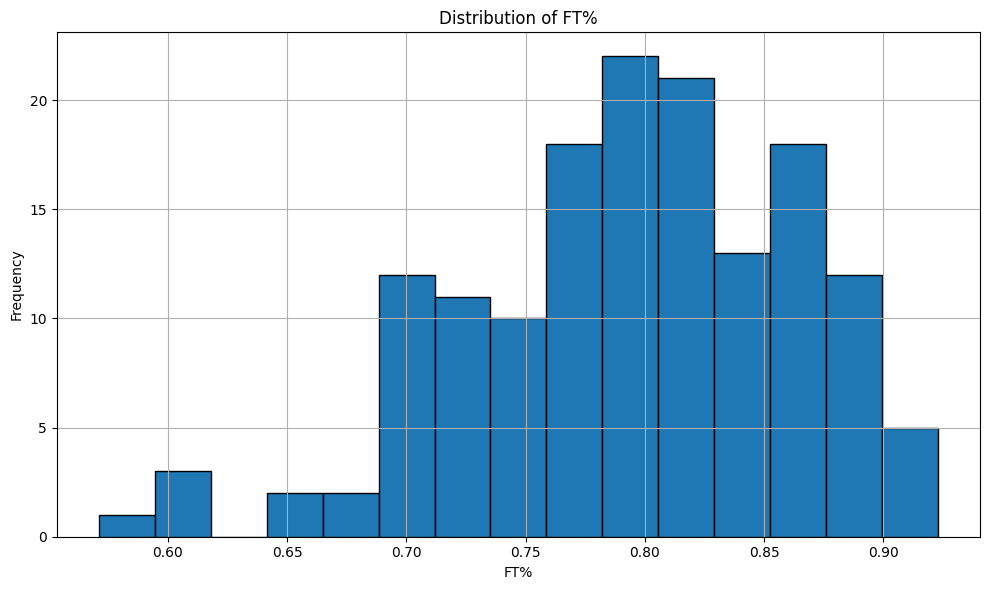

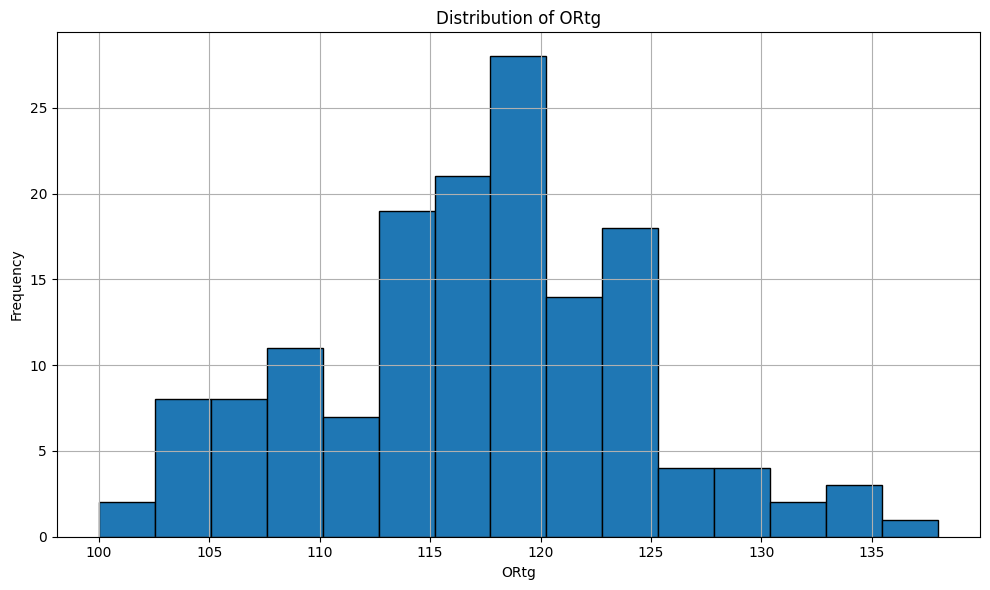

In [ ]:
key_features = ["PTS","AST","TRB","eFG%","FT%","ORtg"]

for col in key_features :
    plt.figure(figsize=(10, 6)) # Adjust figsize as needed for each individual plot
    player_df_rename[col].hist(edgecolor='black', bins=15)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

1. The distribution of PTS, ASTS, RBDs is skewed right, as it aligns more so with many players being around the league average in these categories. The smaller group on the right is evident that high-volume passing/playmaking and scoring (as well as rebounding) can be concentrated among a relative small group of players.

2. FT% is skewed left. Generally guards and forwards have better FT% AND also play a lot of minutes, so this may be impacted by that (will look to confirm if my data selected has significant proportion of guards and forwards).

In [ ]:
#Confirming to see the distribution of positions and the resulting FT% for each
player_df_pos_group = player_df_rename.groupby('Pos').agg(Count=('Pos','size'), Avg_FT = ('FT%','mean')).sort_values('Count',ascending=False)

player_df_pos_group['Avg_FT'] = player_df_pos_group['Avg_FT'].round(2)

player_df_pos_group

,Count,Avg_FT
Pos,,
SG,35,0.82
SF,34,0.79
PG,31,0.82
PF,27,0.77
C,23,0.75


The three most represented positions within our dataset are SG, PG, and SF, which are primarily perimeter-oriented positions. These positions also have the highest average FT%, at around **79-82%**, which is around the benchmark of <u>80%</u> for being a good shooter. That is directly compared to **77%** for PFs and **75%** for Centers.  

Thus, this table confirms why the distribution overall for FT% is skewed left, where guards and wings tend to shoot free throws at *higher* percentages than bigs.

Now, let's take a look beyond these distributions and understand if the statistics can properly group players based on their offensive capabilities.

## **Building the Clustering Model: K-Means Unsupervised**

We are looking to develop a clustering model to group each of these players into offensive effectivness "tier" in order to ask the question: Can Raw + Advanced Stats look to properly group players based on their offensive capabilities?


In [ ]:
#Select the Key Features

In [ ]:
key_features = ["PTS","AST","TRB","eFG%","FT%","ORtg"]


#implement a standardization of the data (StandardScaler)
X = player_df_rename[key_features].copy()

scaler = StandardScaler()
X_transformed = scaler.fit_transform(X)


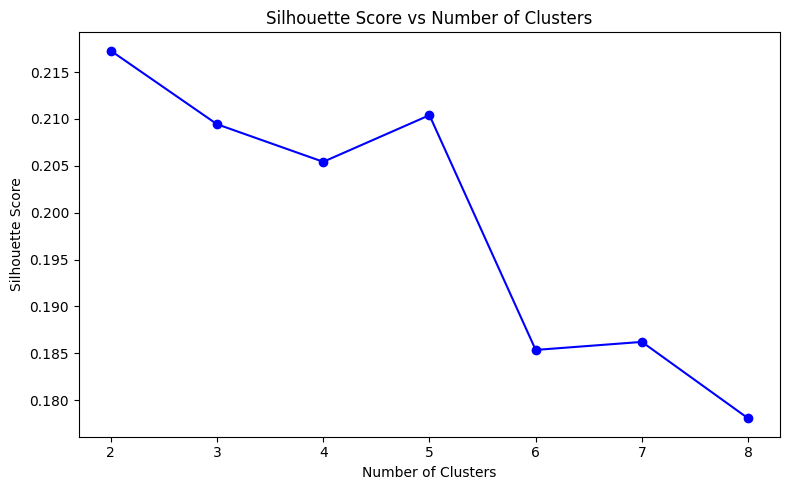

In [ ]:
#Evaluate the Clusters - Determining the Silhouette Scores to determine the # of clusters that bests optimize cohesion, separation, range
#put results into here:

from sklearn.metrics import silhouette_score

silhouette_results =[]

for k in range(2,9):
  test_model = KMeans(n_clusters = k, random_state=42, n_init=20)

  test_labels = test_model.fit_predict(X_transformed)

  #now we can append both the labels and the results into the results dictionary, with silhouette_score

  silhouette_results.append({'Clusters #':k, 'silhoutte_score':silhouette_score(X_transformed, test_labels)})


#create a dataframe out of our results to better visualize
silhouette_df = pd.DataFrame(silhouette_results, index=None)


plt.figure(figsize=(8,5))

plt.plot(silhouette_df['Clusters #'], silhouette_df['silhoutte_score'], color= 'blue', marker = 'o')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')
plt.tight_layout()
plt.show()


#it says use k = 2


## Silhouette Method says we should use K=2, but we should check with another method of determining the number of clusters: the elbow method.


In [ ]:
# we are testing various inertias, defining the drop point in inertia to determine our number of clusters

inertia_results = []

for k in range(1, 9):
  test_cluster_model = KMeans(n_clusters=k,random_state=42, n_init=20)

  test_cluster_model.fit(X_transformed)

  inertia_results.append({"Clusters": k, "Inertia": test_cluster_model.inertia_})

elbow_df = pd.DataFrame(inertia_results)

elbow_df



,Clusters,Inertia
0,1,900.000000
1,2,715.415360
2,3,567.490623
3,4,481.178526
4,5,432.361897
5,6,400.356824
6,7,373.152240
7,8,349.471569


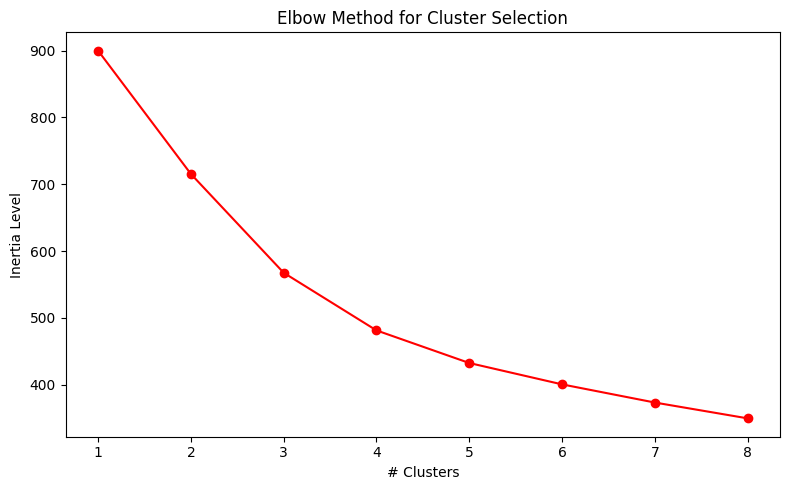

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(elbow_df["Clusters"], elbow_df["Inertia"], color="red", marker="o")

plt.xlabel("# Clusters")
plt.ylabel("Inertia Level")
plt.title("Elbow Method for Cluster Selection")
plt.xticks(range(1, 9))
plt.tight_layout()
plt.show()

#### Silhouette Method gives us k=2, Elbow Method gives us k=3. From an analytical standpoint, NBA players all have a wide variety of skillset and roles on their respective team, so breaking them into more groups will allow us to capture more of the variation and help interpret the differentiations between the players' profiles.

I will also be breaking the players from each cluster into Offensive Tiers later on, so putting them into clustered groups first is good structurally, marking a foundation for identifying offensive archetypes before evaluating differences in offensive effectiveness.


**Below is the Cluster Creation**

In [ ]:
#Define Number of Clusters & Create K-Means Model

num_clusters = 3

kmeans_model = KMeans(n_clusters=num_clusters, random_state=42, n_init=20)

player_df_rename['Cluster'] = kmeans_model.fit_predict(X_transformed) + 1 #to make it not Cluster "0"

## **Examining Our Cluster Results**

In [ ]:
#print out the dataframe
player_df_rename.head(10)

,Player,Team,Pos,Minutes Played,Games,FGA,eFG%,FT%,PTS,AST,TRB,ORtg,Min_per_game,Cluster
0,Amen Thompson,HOU,PG,2953,79,17.7,0.545,0.779,24.4,7.1,10.4,125.0,37.38,1
1,Kevin Durant,HOU,SF,2840,78,24.2,0.588,0.874,35.6,6.5,7.5,124.0,36.41,3
2,Desmond Bane,ORL,SG,2756,82,21.0,0.553,0.908,28.7,5.9,5.9,120.0,33.61,3
3,Toumani Camara,POR,PF,2731,82,15.6,0.563,0.708,19.2,3.5,7.4,115.0,33.30,2
4,Jabari Smith Jr.,HOU,PF,2705,77,18.0,0.541,0.775,22.4,2.6,9.8,120.0,35.13,1
5,Mikal Bridges,NYK,SF,2692,82,17.7,0.571,0.827,21.8,5.6,5.7,125.0,32.83,1
6,Scottie Barnes,TOR,PF,2681,80,20.4,0.537,0.815,26.3,8.6,10.9,116.0,33.51,3
7,Tyrese Maxey,PHI,PG,2661,70,27.2,0.536,0.892,35.9,8.4,5.3,120.0,38.01,3
8,Jamal Murray,DEN,PG,2652,75,25.0,0.573,0.887,35.1,9.8,6.1,126.0,35.36,3
9,Derrick White,BOS,SG,2625,77,21.4,0.489,0.902,24.4,8.0,6.5,117.0,34.09,3


In [ ]:
#clusters detail
cluster_details = player_df_rename.groupby('Cluster')[key_features].mean().round(3)

#per clusters how many players are there
cluster_player_count = player_df_rename.groupby('Cluster')['Player'].count()

#get a summary of the two
cluster_summary = pd.concat([cluster_details, cluster_player_count], axis=1)
cluster_summary = cluster_summary.rename(columns={'Player':'Player Count'})

cluster_summary

,PTS,AST,TRB,eFG%,FT%,ORtg,Player Count
Cluster,,,,,,,
1,23.718,3.982,10.921,0.592,0.768,123.487,39
2,23.258,5.271,8.003,0.526,0.766,110.898,59
3,31.860,8.190,7.510,0.546,0.847,119.615,52


From the table above, we can kind of discern an archetype for each cluster, with Cluster 1 likely forward/center heavy due to the higher level of rebounding, while Cluster 3 is likely guard heavy due to the higher points and assists tallies.

## **Calculate an Offensive Score**

This can define the clusters quantitatively and gives us a greater understanding of what players are the top performers within the clusters (and just overall).

In [ ]:
#Looking Into Scaling the Clusters
#create new dataframe
cluster_df = player_df_rename.copy()

cluster_profile = pd.DataFrame(X_transformed, columns = key_features, index=cluster_df.index)

#define a dictionary of weights to assign to each feature
#I'm looking to weigh PTS & eFG% higher than others, followed by ORtg and AST. Weights should add to 100%.
weight_features = {
    'PTS':.30,
    'AST':.15,
    'TRB':.10,
    'eFG%':.20,
    'FT%':.10,
    'ORtg':.15
}

#create the offensive score column back in our original dataframe
cluster_df['Offense_Score'] = sum(cluster_profile[feature] * weight_features[feature] for feature in key_features)

cluster_df.head(10)

,Player,Team,Pos,Minutes Played,Games,FGA,eFG%,FT%,PTS,AST,TRB,ORtg,Min_per_game,Cluster,Offense_Score
0,Amen Thompson,HOU,PG,2953,79,17.7,0.545,0.779,24.4,7.1,10.4,125.0,37.38,1,0.138272
1,Kevin Durant,HOU,SF,2840,78,24.2,0.588,0.874,35.6,6.5,7.5,124.0,36.41,3,0.870269
2,Desmond Bane,ORL,SG,2756,82,21.0,0.553,0.908,28.7,5.9,5.9,120.0,33.61,3,0.261363
3,Toumani Camara,POR,PF,2731,82,15.6,0.563,0.708,19.2,3.5,7.4,115.0,33.30,2,-0.582266
4,Jabari Smith Jr.,HOU,PF,2705,77,18.0,0.541,0.775,22.4,2.6,9.8,120.0,35.13,1,-0.334054
5,Mikal Bridges,NYK,SF,2692,82,17.7,0.571,0.827,21.8,5.6,5.7,125.0,32.83,1,0.018040
6,Scottie Barnes,TOR,PF,2681,80,20.4,0.537,0.815,26.3,8.6,10.9,116.0,33.51,3,0.135059
7,Tyrese Maxey,PHI,PG,2661,70,27.2,0.536,0.892,35.9,8.4,5.3,120.0,38.01,3,0.579308
8,Jamal Murray,DEN,PG,2652,75,25.0,0.573,0.887,35.1,9.8,6.1,126.0,35.36,3,0.958264
9,Derrick White,BOS,SG,2625,77,21.4,0.489,0.902,24.4,8.0,6.5,117.0,34.09,3,-0.221296


In [ ]:
#organize the dataframe clusters in order by offense_score
cluster_ranking = cluster_df.groupby('Cluster')['Offense_Score'].mean().sort_values(ascending=False).reset_index()

cluster_ranking

,Cluster,Offense_Score
0,3,0.435665
1,1,0.166915
2,2,-0.494310


In [ ]:

#Map based on the offense_score, where Tier 1 is the highest.
#Separate into buckets, with the bottom 40%, middle 40%, and top 20% of players' offense score.

cluster_df['Tier'] = pd.qcut(cluster_df['Offense_Score'], q=[0.00, 0.40, .80, 1.00], labels=['Tier 3', 'Tier 2', 'Tier 1'])


cluster_df.head(10)

,Player,Team,Pos,Minutes Played,Games,FGA,eFG%,FT%,PTS,AST,TRB,ORtg,Min_per_game,Cluster,Offense_Score,Tier
0,Amen Thompson,HOU,PG,2953,79,17.7,0.545,0.779,24.4,7.1,10.4,125.0,37.38,1,0.138272,Tier 2
1,Kevin Durant,HOU,SF,2840,78,24.2,0.588,0.874,35.6,6.5,7.5,124.0,36.41,3,0.870269,Tier 1
2,Desmond Bane,ORL,SG,2756,82,21.0,0.553,0.908,28.7,5.9,5.9,120.0,33.61,3,0.261363,Tier 2
3,Toumani Camara,POR,PF,2731,82,15.6,0.563,0.708,19.2,3.5,7.4,115.0,33.30,2,-0.582266,Tier 3
4,Jabari Smith Jr.,HOU,PF,2705,77,18.0,0.541,0.775,22.4,2.6,9.8,120.0,35.13,1,-0.334054,Tier 3
5,Mikal Bridges,NYK,SF,2692,82,17.7,0.571,0.827,21.8,5.6,5.7,125.0,32.83,1,0.018040,Tier 2
6,Scottie Barnes,TOR,PF,2681,80,20.4,0.537,0.815,26.3,8.6,10.9,116.0,33.51,3,0.135059,Tier 2
7,Tyrese Maxey,PHI,PG,2661,70,27.2,0.536,0.892,35.9,8.4,5.3,120.0,38.01,3,0.579308,Tier 1
8,Jamal Murray,DEN,PG,2652,75,25.0,0.573,0.887,35.1,9.8,6.1,126.0,35.36,3,0.958264,Tier 1
9,Derrick White,BOS,SG,2625,77,21.4,0.489,0.902,24.4,8.0,6.5,117.0,34.09,3,-0.221296,Tier 3


In [ ]:
#Completed results, just reorder the data itself, also translate the labelling of the tiers into something ordinal.

tier_order = ["Tier 1", "Tier 2", "Tier 3"]

#relabel the tiers into ordinal
cluster_df["Tier"] = pd.Categorical(cluster_df["Tier"], categories=tier_order, ordered=True)

defined_results = (
    cluster_df[[
            "Player", "Pos", "Minutes Played", "Min_per_game", "Tier", "Cluster", "Offense_Score"] + key_features
    ].sort_values('Offense_Score', ascending=False))

defined_results.head(15)


,Player,Pos,Minutes Played,Min_per_game,Tier,Cluster,Offense_Score,PTS,AST,TRB,eFG%,FT%,ORtg
44,Nikola Jokić,C,2265,34.85,Tier 1,3,2.068629,38.8,15.0,18.0,0.618,0.831,134.0
48,Shai Gilgeous-Alexander,PG,2259,33.22,Tier 1,3,1.673006,45.3,9.6,6.3,0.597,0.879,133.0
38,Luka Dončić,PG,2289,35.77,Tier 1,3,1.304323,45.7,11.3,10.6,0.563,0.780,120.0
87,Jalen Duren,C,1976,28.23,Tier 1,1,1.277944,33.4,3.4,18.0,0.650,0.747,134.0
69,Kawhi Leonard,SF,2085,32.08,Tier 1,3,1.181032,43.3,5.6,9.9,0.573,0.892,124.0
108,Victor Wembanyama,C,1866,29.16,Tier 1,1,1.165416,41.2,5.1,18.9,0.569,0.827,122.0
245,Stephen Curry,PG,1329,30.91,Tier 1,3,1.093836,41.7,7.4,5.6,0.587,0.923,119.0
8,Jamal Murray,PG,2652,35.36,Tier 1,3,0.958264,35.1,9.8,6.1,0.573,0.887,126.0
32,Donovan Mitchell,SG,2342,33.46,Tier 1,3,0.918753,40.1,8.2,6.5,0.563,0.865,121.0
1,Kevin Durant,SF,2840,36.41,Tier 1,3,0.870269,35.6,6.5,7.5,0.588,0.874,124.0


## **Take a Look Deeper into the Clusters**

I want to start with a PCA to turn the multi-statistic analysis into 2-dimensional visibility. I will note that this likely isn't the most ideal method to view in terms of actual interpretability.

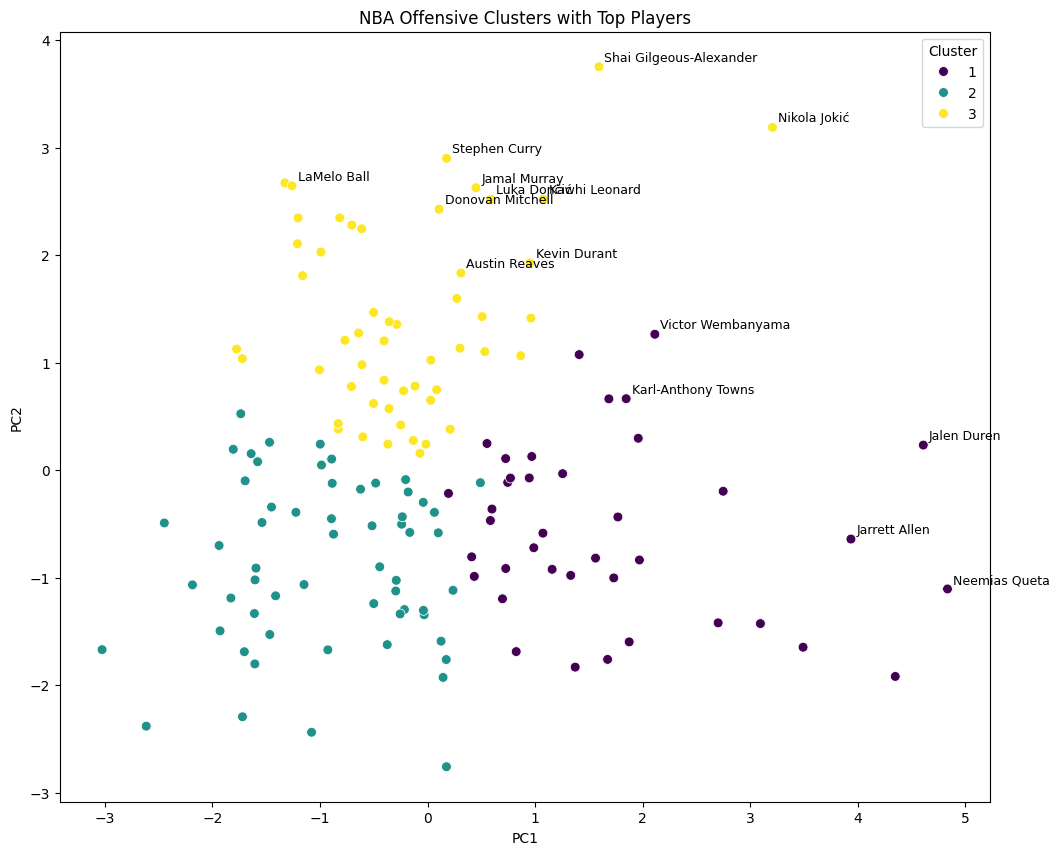

In [ ]:


#Visualize the Top 15 Players and where they fall
from sklearn.decomposition import PCA

plt.figure(figsize=(12, 10))

#define PCA
pca = PCA(n_components=2)
pca_coordinates = pca.fit_transform(X_transformed)

cluster_df["PC1"] = pca_coordinates[:, 0]
cluster_df["PC2"] = pca_coordinates[:, 1]

sns.scatterplot(data=cluster_df, x="PC1", y="PC2",hue="Cluster", hue_order=[1,2,3], palette="viridis", s=50)

#using nlargest get the top 15 players in terms of offense score
#the annotation of these players

top_players = cluster_df.nlargest(15, "Offense_Score")

for player_name, pc1, pc2 in zip(top_players['Player'], top_players['PC1'], top_players['PC2']):
  plt.annotate(player_name, (pc1, pc2), xytext=(4,4), textcoords='offset points', fontsize=9)





plt.title("NBA Offensive Clusters with Top Players")
plt.show()

## **The PCA isn't as Interpretable, so I will try a HeatMap highlighting the average of each standardized statistic per cluster (similar to what I'd do for a correlation matrix)**



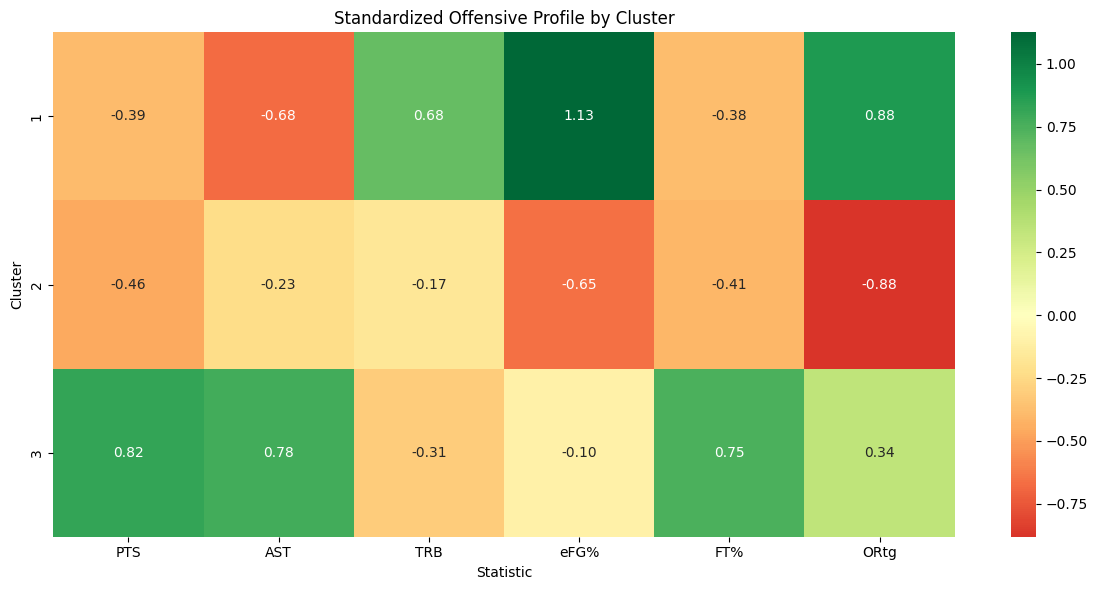

In [ ]:
#Define an Offensive Profile Scatterplot
#we already have the cluster profile above, reuse it

cluster_profile["Cluster"] = cluster_df["Cluster"]

#best way to measure it is by for each individual statistic, determine the mean (transformed)
cluster_profiles = (cluster_profile.groupby("Cluster").mean())

plt.figure(figsize=(12, 6))

sns.heatmap(cluster_profiles, annot=True, cmap="RdYlGn", center=0, fmt=".2f")

plt.title("Standardized Offensive Profile by Cluster")
plt.xlabel("Statistic")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

## **Looking into Individual Clusters, starting with Cluster 3**

In [ ]:
#Cluster 3
cluster_df_three = cluster_df[cluster_df['Cluster'] == 3]
cluster_df_three.head(10)

,Player,Team,Pos,Minutes Played,Games,FGA,eFG%,FT%,PTS,AST,TRB,ORtg,Min_per_game,Cluster,Offense_Score,Tier,PC1,PC2
1,Kevin Durant,HOU,SF,2840,78,24.2,0.588,0.874,35.6,6.5,7.5,124.0,36.41,3,0.870269,Tier 1,0.952054,1.926527
2,Desmond Bane,ORL,SG,2756,82,21.0,0.553,0.908,28.7,5.9,5.9,120.0,33.61,3,0.261363,Tier 2,-0.286887,1.354560
6,Scottie Barnes,TOR,PF,2681,80,20.4,0.537,0.815,26.3,8.6,10.9,116.0,33.51,3,0.135059,Tier 2,-0.250373,0.418857
7,Tyrese Maxey,PHI,PG,2661,70,27.2,0.536,0.892,35.9,8.4,5.3,120.0,38.01,3,0.579308,Tier 1,-0.704451,2.278336
8,Jamal Murray,DEN,PG,2652,75,25.0,0.573,0.887,35.1,9.8,6.1,126.0,35.36,3,0.958264,Tier 1,0.449190,2.625748
9,Derrick White,BOS,SG,2625,77,21.4,0.489,0.902,24.4,8.0,6.5,117.0,34.09,3,-0.221296,Tier 3,-1.722170,1.035821
11,Julius Randle,MIN,PF,2610,79,22.1,0.526,0.802,30.5,7.3,9.7,117.0,33.04,3,0.162560,Tier 2,-0.358817,0.571035
13,Nickeil Alexander-Walker,ATL,SG,2603,78,21.7,0.564,0.902,29.5,5.2,4.9,117.0,33.37,3,0.219466,Tier 2,-0.404293,1.201802
14,Jalen Brunson,NYK,PG,2590,74,28.2,0.533,0.841,36.9,9.6,4.7,122.0,35.00,3,0.620832,Tier 1,-0.612883,2.243770
15,Payton Pritchard,BOS,PG,2556,79,21.6,0.561,0.890,26.6,8.1,6.2,126.0,32.35,3,0.433908,Tier 2,0.271905,1.595507


In [ ]:
#Look at the distribution of G, F, C
cluster_df_three_distribution = cluster_df_three.groupby('Pos').size().rename('Count').sort_values(ascending=False).reset_index()
cluster_df_three_distribution

#Confirms our earlier theory that the majority of those in Cluster 3 are guards.

,Pos,Count
0,PG,22
1,SG,12
2,SF,10
3,PF,7
4,C,1


#### Taking a Look at the Distribution of PTS scored per 100 vs. eFG% (measuring aggregate scoring vs. efficiency in scoring)

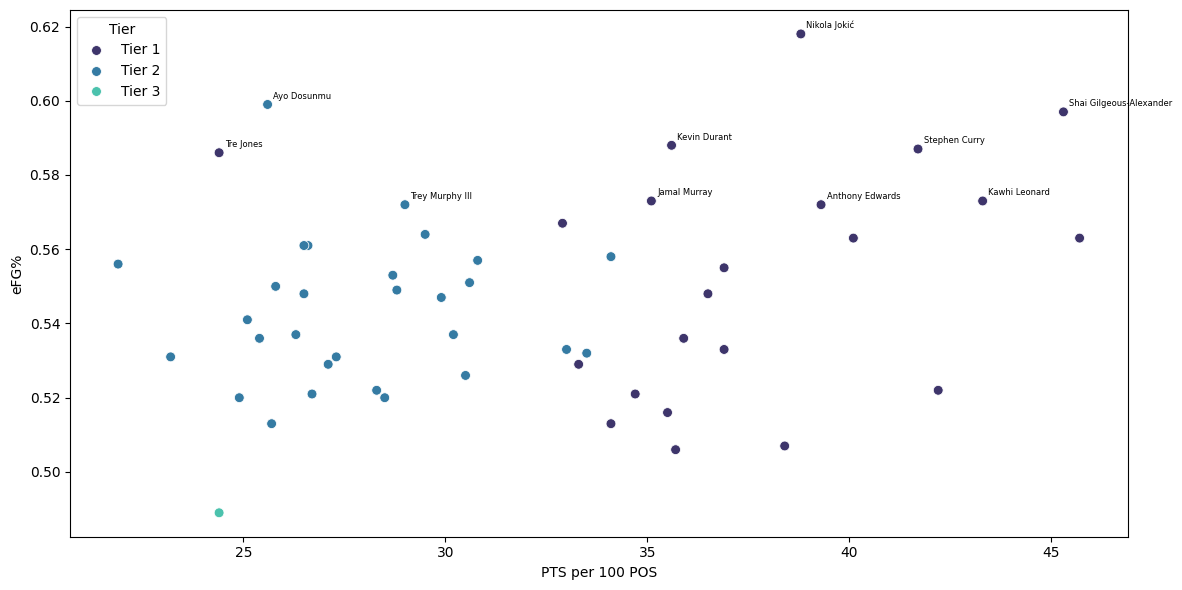

In [ ]:
#label the top 10 in terms of eFG%. Seeing as it is so low average wise in the cluster (standardized), I want to see those who stand out
top_players_three = cluster_df_three.nlargest(10, "eFG%")

plt.figure(figsize=(12, 6))
sns.scatterplot(data= cluster_df_three, x="PTS", y="eFG%", hue="Tier", hue_order=tier_order, palette="mako", s=50)
plt.xlabel('PTS per 100 POS')
plt.ylabel('eFG%')

#annotate
for player_name, x, y in zip(top_players_three['Player'], top_players_three['PTS'], top_players_three['eFG%']):
  plt.annotate(player_name, (x, y), xytext=(4,4), textcoords='offset points', fontsize=6)



plt.tight_layout()
plt.show()

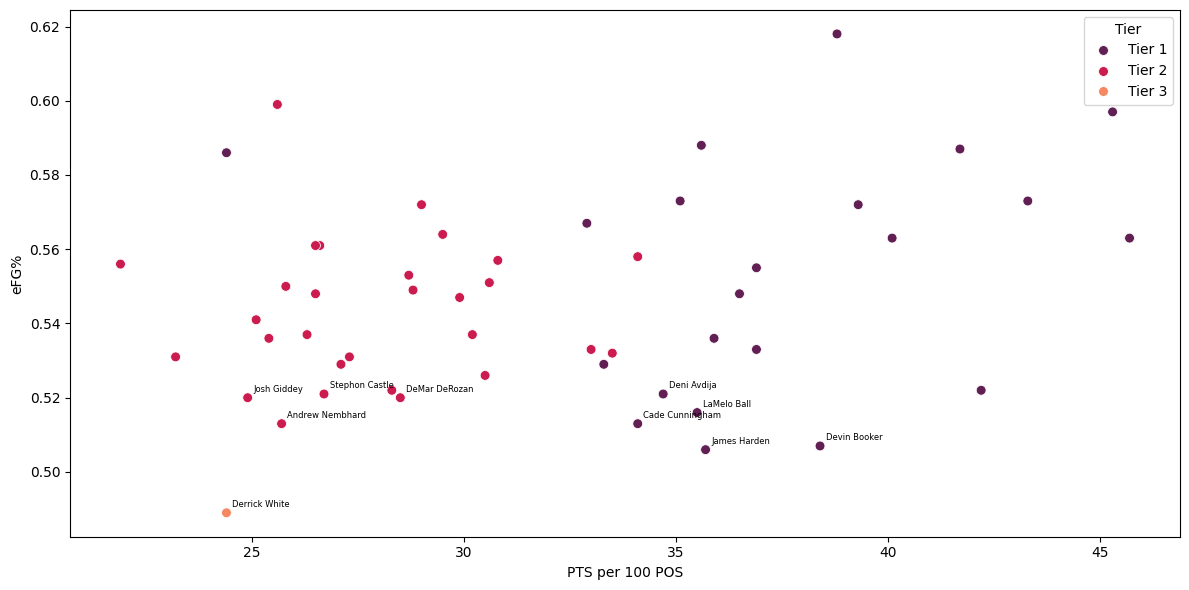

In [ ]:
#Lowest in eFG%
bottom_players_three = cluster_df_three.nsmallest(10, "eFG%")

plt.figure(figsize=(12, 6))
sns.scatterplot(data= cluster_df_three, x="PTS", y="eFG%", hue="Tier", hue_order=tier_order, palette="rocket", s=50)
plt.xlabel('PTS per 100 POS')
plt.ylabel('eFG%')

#annotate
for player_name, x, y in zip(bottom_players_three['Player'], bottom_players_three['PTS'], bottom_players_three['eFG%']):
  plt.annotate(player_name, (x, y), xytext=(4,4), textcoords='offset points', fontsize=6)



plt.tight_layout()
plt.show()

## Key Interpretations:

**1.** I find it very interesting that the top 2 leaders in MVP voting last season (Shai Gilgeous-Alexander and Nikola Jokic) are two of the very highest in **eFG% & PTs.** The most valuable offensive profile combines high scoring volume with strong efficiency at the rim and from three, which these two can both do very well.

**2.** It is evident that most Tier 2 players fall into the more lower-efficiency, lower-scoring category (in relation to the rest of the group). It is likely that they are more complementary players or operate best not as the No. 1 option.

**3.** Players in Cluster 3 overall are roughly split between 2 profiles: <u>low pts but efficient, higher pts but less efficient.</u> The top players tend to separate from the pack towards the right.

**4.** These players that are bottom 10 in eFG% also can be grouped into <u>individual offensive archetypes</u>: Derrick White, Andrew Nembhard and Stephon Castle are high point-of-attack defenders who take secondary ball-handling on offense, DeMar and Devin Booker are primarily mid-range scorers, and James Harden, Deni Avdija, Cade Cunningham, Josh Giddey, and LaMelo Ball are high-usage, pick-and-roll heavy distributors.

**5.** Meanwhile, with the exception of Jokic, many of the top players in eFG% like Curry, Leonard, Durant, and Edwards primarily create value through their scoring and using that gravity to generate easier looks for the rest of their teammates. Curry, especially, provides a significant value through off-ball movement and scoring that opens up many easy shots, given that teams want to take away his deadly accuracy from three first.

Ultimately, the key **takeaway** is that while there is role specialization and differing skillsets, the NBA has shifted to a league where players can contribute in multiple areas. This can help explain why the players do not separate into perfectly distinct clusters, as K-means measures similarity across all selected statistics rather than one variable. *Despite this overlap,* the model still did a good job of grouping players based on their similar statistics with differing offensive characteristics.



Including the Tier system enables us to figure out within those with similar statistical profiles, how strongly and efficiently they perform under those same profiles. Even if Player A and Player B may have the same stats/skillsets, the value they generate for their team's offense can still differ based on their level of efficiency and magnitude of production.

## **Next Steps**

1. Analyze the other two clusters to define what type of players fall into those.

2. Analyze overarching trends of offensive_score across clusters.

3. Incorporate more statistics, including turnovers, usage rate, true shooting percentage, and on/off metrics (how much better the team was with the player vs. without)

4. Look into the actual teams the players play on and see if the team's overall offensive rating (affected by combination of the personnel, offensive philosophy, and even defensive ratings) can impact the offensive effectiveness of a player.

5. After these statistics, look more into EPM, O-LEBRON, VORP, and other even more ADVANCED Metrics.